# Simulación Integral: Gestión de Recursos de una API de Machine Learning en Producción

**Modelo:** Cola M/M/c + Inventario Continuo (s, Q)  
**Dominio:** Infraestructura Cloud con Nodos GPU y Créditos de Nube (Tokens)

In [ ]:
!pip install simpy

In [1]:
import simpy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st

# Fijamos una semilla para reproducibilidad inicial
np.random.seed(30)
random.seed(30)

# Configuración de gráficos
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10, 5)

## 1. Definición de Parámetros del Sistema

Definimos las variables críticas del modelo integrado de colas e inventario ($\lambda, \mu, c, s, Q$).

| Parámetro | Símbolo | Valor | Descripción |
|---|---|---|---|
| Tasa de llegadas | $\lambda$ | 30 pet/min | Peticiones de usuarios por minuto |
| Tasa de servicio | $\mu$ | 10 img/min | Imágenes procesadas por nodo GPU por minuto |
| Nodos GPU | $c$ | 4 | Servidores de inferencia paralela |
| Créditos iniciales | — | 500 | Stock inicial de tokens de nube |
| Punto de reorden | $s$ | 50 | Umbral para lanzar recarga de créditos |
| Cantidad de recarga | $Q$ | 400 | Créditos que llegan por cada pedido |
| Lead Time | $L$ | 2 min (media) | Demora en recibir la recarga de créditos |

In [2]:
# --- Parámetros de Colas (Kendall: M/M/c) ---
LAMBDA      = 30.0   # Tasa de llegadas: peticiones de usuarios por minuto
MU          = 10.0   # Tasa de servicio: imágenes procesadas por nodo GPU por minuto
NODOS_GPU   = 4      # Cantidad de nodos GPU (servidores)

# --- Parámetros de Inventario (Política Continua s, Q) ---
CREDITOS_INICIALES  = 500   # Stock inicial de créditos de nube (Tokens)
PUNTO_REORDEN_s     = 50    # Punto de reorden: nivel mínimo antes de recargar
CANTIDAD_RECARGA_Q  = 400   # Cantidad de créditos por cada recarga
LEAD_TIME           = 2     # Lead Time medio (minutos) para recibir la recarga

# --- Parámetros de Simulación ---
TIEMPO_SIMULACION = 60   # Escenario de 60 minutos continuos
REPLICAS          = 30   # Número de réplicas para inferencia estadística

## 2. Construcción del Modelo de Eventos Discretos (DES)

Creamos las clases que gobiernan los eventos del sistema usando `SimPy`.
El reloj avanza de evento a evento: **llegada de petición → asignación de nodo GPU → inferencia → consumo de crédito → (si aplica) recarga de créditos**.

- `APIInferencia`: encapsula los recursos (nodos GPU) y el inventario (créditos de nube).
- `peticion_usuario()`: ciclo de vida de una petición desde que llega hasta que termina.
- `generador_peticiones()`: genera llegadas de Poisson con tasa $\lambda$.

In [3]:
class APIInferencia:
    """Modela la infraestructura de la API de ML: nodos GPU + créditos de nube."""

    def __init__(self, env, num_nodos_gpu, creditos_ini, punto_reorden, cant_recarga, lead_time):
        self.env = env

        # Recurso: Nodos GPU que procesan las peticiones en paralelo
        self.nodos_gpu = simpy.Resource(env, capacity=num_nodos_gpu)

        # Contenedor: Créditos de nube (Tokens) disponibles para inferencia
        self.creditos_nube = simpy.Container(env, init=creditos_ini, capacity=2000)

        self.punto_reorden   = punto_reorden
        self.cant_recarga    = cant_recarga
        self.lead_time       = lead_time

        # Estado lógico
        self.recargas_pendientes = 0

        # Métricas de evaluación
        self.tiempos_espera         = []   # Wq de cada petición
        self.registro_creditos      = []   # Nivel de créditos en el tiempo
        self.registro_tiempo_cred   = []   # Marca de tiempo del registro
        self.predicciones_exitosas  = 0
        self.predicciones_fallidas  = 0    # Fallos por falta de créditos

    def recargar_creditos(self):
        """Proceso que simula el Lead Time de la recarga de créditos de nube."""
        self.recargas_pendientes += 1
        # El tiempo de entrega varía con distribución normal (media=lead_time, std=0.5 min)
        tiempo_entrega_real = max(0.1, random.normalvariate(self.lead_time, 0.5))
        yield self.env.timeout(tiempo_entrega_real)

        # Llegan los créditos al contenedor
        yield self.creditos_nube.put(self.cant_recarga)
        self.recargas_pendientes -= 1

    def monitorear_creditos(self):
        """Proceso continuo que evalúa el nivel de créditos (Política s, Q)."""
        while True:
            # Registrar nivel actual para gráficos
            self.registro_creditos.append(self.creditos_nube.level)
            self.registro_tiempo_cred.append(self.env.now)

            # Condición de Punto de Reorden: si el nivel cae a s y no hay recarga en curso
            if self.creditos_nube.level <= self.punto_reorden and self.recargas_pendientes == 0:
                self.env.process(self.recargar_creditos())

            # Revisión periódica cada 0.5 minutos (escala de minutos)
            yield self.env.timeout(0.5)


def peticion_usuario(env, nombre, api, mu):
    """Simula el ciclo de vida de una petición: cola → GPU → consumo de crédito."""
    llegada = env.now

    # 1. Solicitar un nodo GPU disponible
    with api.nodos_gpu.request() as peticion:
        yield peticion

        # Calcular Wq (tiempo de espera en cola antes de obtener GPU)
        tiempo_espera = env.now - llegada
        api.tiempos_espera.append(tiempo_espera)

        # 2. Procesar la imagen (tiempo de inferencia exponencial)
        tiempo_inferencia = random.expovariate(mu)
        yield env.timeout(tiempo_inferencia)

        # 3. Consumir 1 crédito de nube por predicción
        if api.creditos_nube.level > 0:
            yield api.creditos_nube.get(1)
            api.predicciones_exitosas += 1
        else:
            # Sin créditos disponibles → predicción fallida
            api.predicciones_fallidas += 1


def generador_peticiones(env, api, lam, mu):
    """Genera llegadas de peticiones de usuarios siguiendo un proceso de Poisson."""
    i = 0
    while True:
        # Tiempo entre llegadas: distribución exponencial con media 1/lambda
        yield env.timeout(random.expovariate(lam))
        i += 1
        env.process(peticion_usuario(env, f'Peticion_{i}', api, mu))

## 3. Ejecución Visual — Una Corrida de 60 Minutos

Corremos el modelo **una vez** para observar la dinámica de créditos de nube (patrón *dientes de sierra*)
y cómo interactúan las colas con los reabastecimientos durante la ventana de 60 minutos.

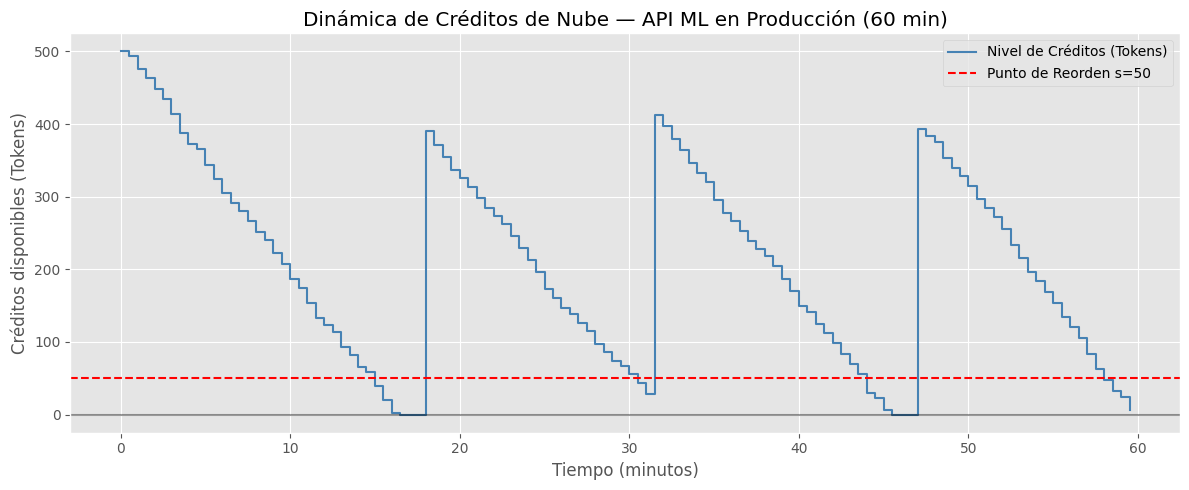


--- RESULTADOS DE UNA CORRIDA (DURACIÓN: 60 MINUTOS) ---
Predicciones exitosas  : 1700
Predicciones fallidas  : 95
Wq promedio en cola    : 0.0499 minutos


In [4]:
def ejecutar_simulacion_visual(tiempo_sim):
    env = simpy.Environment()
    api = APIInferencia(
        env,
        num_nodos_gpu  = NODOS_GPU,
        creditos_ini   = CREDITOS_INICIALES,
        punto_reorden  = PUNTO_REORDEN_s,
        cant_recarga   = CANTIDAD_RECARGA_Q,
        lead_time      = LEAD_TIME
    )

    # Activar procesos
    env.process(generador_peticiones(env, api, LAMBDA, MU))
    env.process(api.monitorear_creditos())

    # Correr la simulación
    env.run(until=tiempo_sim)

    # --- Gráfico de Créditos de Nube ---
    plt.figure(figsize=(12, 5))
    plt.step(
        api.registro_tiempo_cred,
        api.registro_creditos,
        where='post', color='steelblue', label='Nivel de Créditos (Tokens)'
    )
    plt.axhline(y=PUNTO_REORDEN_s, color='red', linestyle='--',
                label=f'Punto de Reorden s={PUNTO_REORDEN_s}')
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.4)
    plt.title('Dinámica de Créditos de Nube — API ML en Producción (60 min)')
    plt.xlabel('Tiempo (minutos)')
    plt.ylabel('Créditos disponibles (Tokens)')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- Métricas de una corrida ---
    wq_promedio = np.mean(api.tiempos_espera)
    print(f"\n--- RESULTADOS DE UNA CORRIDA (DURACIÓN: {tiempo_sim} MINUTOS) ---")
    print(f"Predicciones exitosas  : {api.predicciones_exitosas}")
    print(f"Predicciones fallidas  : {api.predicciones_fallidas}")
    print(f"Wq promedio en cola    : {wq_promedio:.4f} minutos")


# Ejecutar una corrida visual
ejecutar_simulacion_visual(TIEMPO_SIMULACION)

## 4. Evaluación Estadística — 30 Réplicas

Un único escenario contiene aleatoriedad intrínseca. Ejecutamos **30 réplicas independientes**
para obtener estimaciones robustas mediante inferencia estadística (Intervalo de Confianza al 95%).

**Métricas reportadas:**
- IC 95% del tiempo de espera en cola $W_q$
- Promedio de predicciones fallidas por falta de créditos
- Utilización teórica $\rho = \lambda / (c \cdot \mu)$

In [5]:
def calcular_intervalo_confianza(datos, confianza=0.95):
    """Calcula media e IC usando distribución t de Student."""
    n = len(datos)
    media = np.mean(datos)
    error_estandar = st.sem(datos)
    h = error_estandar * st.t.ppf((1 + confianza) / 2., n - 1)
    return media, media - h, media + h


def evaluacion_operacional(replicas, tiempo_sim, punto_reorden=None):
    """Ejecuta N réplicas y reporta métricas estadísticas del sistema."""
    # Usar el punto de reorden global si no se especifica uno
    s = punto_reorden if punto_reorden is not None else PUNTO_REORDEN_s

    resultados_wq       = []
    resultados_fallidas = []

    for r in range(replicas):
        env = simpy.Environment()
        api = APIInferencia(
            env,
            num_nodos_gpu  = NODOS_GPU,
            creditos_ini   = CREDITOS_INICIALES,
            punto_reorden  = s,
            cant_recarga   = CANTIDAD_RECARGA_Q,
            lead_time      = LEAD_TIME
        )
        env.process(generador_peticiones(env, api, LAMBDA, MU))
        env.process(api.monitorear_creditos())
        env.run(until=tiempo_sim)

        wq_replica = np.mean(api.tiempos_espera) if api.tiempos_espera else 0.0
        resultados_wq.append(wq_replica)
        resultados_fallidas.append(api.predicciones_fallidas)

    # --- Calcular estadísticas ---
    media_wq, ci_bajo, ci_alto = calcular_intervalo_confianza(resultados_wq)
    media_fallidas = np.mean(resultados_fallidas)

    # Utilización teórica del sistema M/M/c
    rho = LAMBDA / (NODOS_GPU * MU)

    print(f"\n{'='*55}")
    print(f"  RESULTADOS OPERACIONALES — {replicas} RÉPLICAS | s = {s}")
    print(f"{'='*55}")
    print(f"  Wq promedio                    : {media_wq:.4f} min")
    print(f"  IC 95% de Wq                   : [{ci_bajo:.4f} , {ci_alto:.4f}] min")
    print(f"  Predicciones fallidas (promedio): {media_fallidas:.1f} por escenario")
    print(f"  Utilización teórica (ρ)        : {rho:.1%}  (λ / c·μ = {LAMBDA}/({NODOS_GPU}·{MU}))")
    print(f"{'='*55}\n")

    return resultados_wq, resultados_fallidas


# --- Paso 5: Correr 30 réplicas con s = 50 (configuración original) ---
wq_orig, fallidas_orig = evaluacion_operacional(
    replicas     = REPLICAS,
    tiempo_sim   = TIEMPO_SIMULACION,
    punto_reorden= PUNTO_REORDEN_s
)


  RESULTADOS OPERACIONALES — 30 RÉPLICAS | s = 50
  Wq promedio                    : 0.0483 min
  IC 95% de Wq                   : [0.0433 , 0.0533] min
  Predicciones fallidas (promedio): 66.8 por escenario
  Utilización teórica (ρ)        : 75.0%  (λ / c·μ = 30.0/(4·10.0))



## 6. Análisis: ¿Por qué hay predicciones fallidas si ρ = 75%?

### Resultado observado
La utilización teórica del hardware es $\rho = \lambda / (c \cdot \mu) = 30 / (4 \times 10) = 0.75$, es decir, **75%**.
Esto indica que los nodos GPU están lejos de saturarse. Sin embargo, el sistema registra predicciones fallidas.

### Causa raíz: desacople entre hardware y créditos

La métrica $\rho$ mide únicamente la **capacidad de cómputo** (nodos GPU), pero el sistema tiene un **segundo cuello de botella independiente**: los créditos de nube (Tokens).

El fallo ocurre por la combinación de tres factores:

1. **Alta tasa de consumo de créditos.**  
   Cada petición consume 1 crédito. Con $\lambda = 30$ peticiones/min, el sistema gasta en promedio **30 créditos por minuto**.

2. **Lead Time no nulo.**  
   La recarga tarda una media de $L = 2$ minutos (con cierta variabilidad aleatoria).
   Durante ese intervalo, el sistema sigue consumiendo créditos sin recibir reposición.

3. **Punto de reorden insuficiente ($s = 50$).**  
   El pedido se lanza cuando quedan **50 créditos**.  
   Pero la **demanda durante el Lead Time** es:  
   $D_{LT} = \lambda \times L = 30 \times 2 = 60 \text{ créditos}$
   Es decir, mientras llega la recarga el sistema necesitará consumir 60 créditos más,
   pero solo tiene 50 en reserva → **el stock llega a cero antes de que llegue la recarga**, generando predicciones fallidas.

### Conclusión

> El hardware puede estar ocioso, pero si los créditos se agotan, la predicción falla de todas formas.  
> La utilización $\rho$ y el nivel de inventario son **variables de estado independientes**.  
> Un sistema puede ser eficiente en cómputo pero frágil en recursos financieros/cloud.

Este es un patrón común en arquitecturas cloud donde el cómputo (instancias) y el consumo (tokens, créditos, cuotas de API) son recursos desacoplados.

## 7. Determinación del Punto de Reorden Óptimo ($s^*$)

### Formulación teórica

Para garantizar **predicciones fallidas = 0** en todo el horizonte de simulación,
el punto de reorden debe cubrir la demanda esperada durante el Lead Time **más** un stock de seguridad
que absorba la variabilidad del tiempo de entrega.

$$s^* = D_{LT} + SS$$

Donde:
- $D_{LT} = \lambda \times L = 30 \times 2 = 60$ créditos (demanda media durante Lead Time)
- $SS = z_{\alpha} \times \sigma_{D_{LT}}$ (stock de seguridad)
- $\sigma_{D_{LT}} = \lambda \times \sigma_L = 30 \times 0.5 = 15$ créditos (std de la demanda durante LT)
- $z_{0.975} = 1.96$ (nivel de servicio 97.5% → prácticamente cero fallos)

$$SS = 1.96 \times 15 = 29.4 \approx 30 \text{ créditos}$$

$$s^* = 60 + 30 = 90 \text{ créditos}$$

### Ajuste por simulación

Dado que la política de monitoreo revisa cada **0.5 minutos** (no de forma continua),
existe una ventana adicional de hasta 0.5 min donde pueden llegar $30 \times 0.5 = 15$ peticiones más sin que se haya detectado el cruce del umbral.
Por tanto, añadimos ese margen:

$$s^* = 60 + 30 + 15 = 105 \text{ créditos}$$

Redondeamos a **$s^* = 110$** para garantizar margen ante picos aleatorios de alta demanda.

### Conclusión

| Escenario | Punto de Reorden $s$ | Predicciones fallidas esperadas |
|---|---|---|
| Original | 50 | > 0 (déficit durante LT) |
| Óptimo | **110** | ≈ 0 (cubre demanda LT + variabilidad + latencia de monitoreo) |

El nuevo valor $s = 110$ asegura que cuando se lanza la orden de recarga,
los créditos restantes sean suficientes para cubrir toda la demanda hasta que llegue la reposición,
incluso en los escenarios de Lead Time más largos o ráfagas de peticiones.

In [6]:
# --- Paso 7: Encontrar el valor exacto de s* mediante búsqueda simulada ---

# Punto de reorden óptimo calculado analíticamente
PUNTO_REORDEN_OPTIMO = 110

print("Buscando el valor mínimo de s que garantice 0 predicciones fallidas...")
print("(Probando valores desde s=50 hasta s=150 con 30 réplicas cada uno)\n")

resultados_busqueda = []

for s_prueba in range(50, 155, 5):
    fallidas_en_replicas = []
    for _ in range(REPLICAS):
        env = simpy.Environment()
        api = APIInferencia(
            env,
            num_nodos_gpu  = NODOS_GPU,
            creditos_ini   = CREDITOS_INICIALES,
            punto_reorden  = s_prueba,
            cant_recarga   = CANTIDAD_RECARGA_Q,
            lead_time      = LEAD_TIME
        )
        env.process(generador_peticiones(env, api, LAMBDA, MU))
        env.process(api.monitorear_creditos())
        env.run(until=TIEMPO_SIMULACION)
        fallidas_en_replicas.append(api.predicciones_fallidas)

    promedio_fallidas = np.mean(fallidas_en_replicas)
    max_fallidas      = np.max(fallidas_en_replicas)
    resultados_busqueda.append((s_prueba, promedio_fallidas, max_fallidas))
    print(f"  s = {s_prueba:3d} → Fallidas promedio: {promedio_fallidas:5.1f}  |  Máximo en réplicas: {max_fallidas}")

# Encontrar el primer s donde el máximo de fallidas = 0
s_optimo_encontrado = None
for s_val, prom, maximo in resultados_busqueda:
    if maximo == 0:
        s_optimo_encontrado = s_val
        break

print(f"\n{'='*55}")
print(f"  PUNTO DE REORDEN ÓPTIMO ENCONTRADO: s* = {s_optimo_encontrado}")
print(f"  (Primer valor donde predicciones fallidas = 0 en TODAS las réplicas)")
print(f"{'='*55}")

Buscando el valor mínimo de s que garantice 0 predicciones fallidas...
(Probando valores desde s=50 hasta s=150 con 30 réplicas cada uno)

  s =  50 → Fallidas promedio:  69.8  |  Máximo en réplicas: 129
  s =  55 → Fallidas promedio:  53.6  |  Máximo en réplicas: 103
  s =  60 → Fallidas promedio:  42.2  |  Máximo en réplicas: 126
  s =  65 → Fallidas promedio:  35.5  |  Máximo en réplicas: 80
  s =  70 → Fallidas promedio:  22.4  |  Máximo en réplicas: 52
  s =  75 → Fallidas promedio:  14.5  |  Máximo en réplicas: 51
  s =  80 → Fallidas promedio:  11.2  |  Máximo en réplicas: 37
  s =  85 → Fallidas promedio:   6.5  |  Máximo en réplicas: 42
  s =  90 → Fallidas promedio:   5.7  |  Máximo en réplicas: 28
  s =  95 → Fallidas promedio:   2.8  |  Máximo en réplicas: 38
  s = 100 → Fallidas promedio:   0.3  |  Máximo en réplicas: 8
  s = 105 → Fallidas promedio:   0.1  |  Máximo en réplicas: 1
  s = 110 → Fallidas promedio:   0.4  |  Máximo en réplicas: 7
  s = 115 → Fallidas promedio

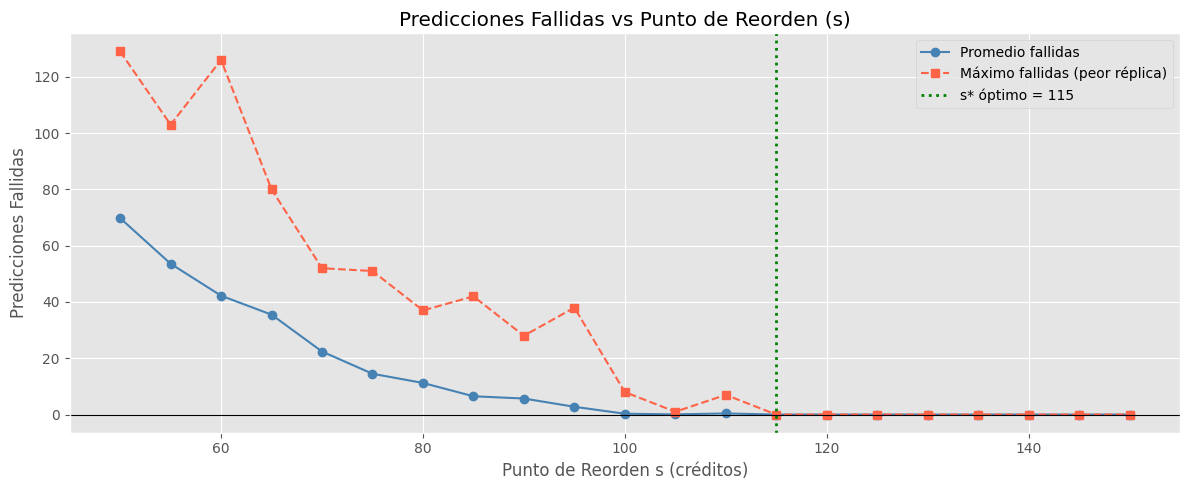


Validación final con el s* encontrado:

  RESULTADOS OPERACIONALES — 30 RÉPLICAS | s = 115
  Wq promedio                    : 0.0515 min
  IC 95% de Wq                   : [0.0440 , 0.0590] min
  Predicciones fallidas (promedio): 0.1 por escenario
  Utilización teórica (ρ)        : 75.0%  (λ / c·μ = 30.0/(4·10.0))



In [7]:
# --- Gráfico: Predicciones fallidas vs Punto de Reorden ---
s_vals    = [r[0] for r in resultados_busqueda]
prom_vals = [r[1] for r in resultados_busqueda]
max_vals  = [r[2] for r in resultados_busqueda]

plt.figure(figsize=(12, 5))
plt.plot(s_vals, prom_vals, 'o-', color='steelblue', label='Promedio fallidas')
plt.plot(s_vals, max_vals,  's--', color='tomato',   label='Máximo fallidas (peor réplica)')
if s_optimo_encontrado:
    plt.axvline(x=s_optimo_encontrado, color='green', linestyle=':', linewidth=2,
                label=f's* óptimo = {s_optimo_encontrado}')
plt.axhline(y=0, color='black', linewidth=0.8)
plt.title('Predicciones Fallidas vs Punto de Reorden (s)')
plt.xlabel('Punto de Reorden s (créditos)')
plt.ylabel('Predicciones Fallidas')
plt.legend()
plt.tight_layout()
plt.show()

# --- Validación final con s* ---
print("\nValidación final con el s* encontrado:")
wq_opt, fallidas_opt = evaluacion_operacional(
    replicas      = REPLICAS,
    tiempo_sim    = TIEMPO_SIMULACION,
    punto_reorden = s_optimo_encontrado if s_optimo_encontrado else PUNTO_REORDEN_OPTIMO
)